## Dataset: PANDA

[PANDA](https://www.kaggle.com/c/prostate-cancer-grade-assessment) (Prostate cANcer graDe Assessment) is a Kaggle-hosted whole-slide image (WSI) dataset for automated ISUP grading of prostate biopsies. Unlike PathMNIST and CAMELYON17, it ships as raw gigapixel WSIs rather than pre-extracted patches, and it combines data from two institutions with different labeling protocols.

- **`train.csv`** — per-slide metadata: `image_id`, `data_provider` (`radboud` or `karolinska`), `isup_grade` (0-5, the target label), and `gleason_score` (the underlying Gleason pattern, e.g. `3+4`, `negative`).
- **`train_images/{image_id}.tiff`** — multi-resolution pyramidal TIFFs (full slide, not patches). Opening these needs [OpenSlide](https://openslide.org/) rather than a plain image loader.
- **`train_label_masks/{image_id}_mask.tiff`** — pixel-level annotation masks, only available for a subset of slides. Mask label semantics differ between the two data providers (see the [data description](https://www.kaggle.com/c/prostate-cancer-grade-assessment/data) for the per-provider color/label legend).

You can load `train.csv` to get an overview of grade balance and provider split, then use OpenSlide to pull low-resolution thumbnails of a few slides to visualize.

In [ ]:
import sys
sys.path.append("/home/shared/helper/")
from nbhelper import (
    plt,
    np,
    pd,
    sns,
)

import openslide
from pathlib import Path
from glob import glob

In [29]:
panda_base_dir = "/home/shared/data/panda/"
train_images_dir = panda_base_dir + "train_images/"
train_masks_dir = panda_base_dir + "train_label_masks/"

train_df = (
    pd.read_csv(panda_base_dir + "train.csv")
    .assign(filepath=lambda x: x["image_id"].apply(lambda y: str(Path(train_images_dir) / f"{y}.tiff")))
    .assign(exists=lambda x: x["filepath"].apply(lambda y: Path(y).exists()))
    .loc[lambda x: x["exists"]]
)
train_df

,image_id,data_provider,isup_grade,gleason_score,filepath,exists
599,0f1ea91c9f917bb3d198f02fd432e4ce,radboud,0,negative,/home/shared/data/panda/train_images/0f1ea91c9...,True
695,117e082dcd41f3e3244100693ceef2b8,karolinska,0,0+0,/home/shared/data/panda/train_images/117e082dc...,True
880,164b35a1b6e77358640cd0d8554e396c,karolinska,0,0+0,/home/shared/data/panda/train_images/164b35a1b...,True
1196,1e642b4f5afa230c341c6622461dd48b,karolinska,0,0+0,/home/shared/data/panda/train_images/1e642b4f5...,True
1666,29d70921c5346342007bb79603c58303,radboud,0,negative,/home/shared/data/panda/train_images/29d70921c...,True
...,...,...,...,...,...,...
9477,e5a167f697628add6a45ea4e447465bd,karolinska,1,3+3,/home/shared/data/panda/train_images/e5a167f69...,True
9494,e62030f62fb52831cb29a000510c94a0,karolinska,0,0+0,/home/shared/data/panda/train_images/e62030f62...,True
9550,e76c7b4cbca487702e96526bf01bc165,karolinska,0,0+0,/home/shared/data/panda/train_images/e76c7b4cb...,True
10472,fce06ebb6c102f4f526a09e8273bded9,karolinska,0,0+0,/home/shared/data/panda/train_images/fce06ebb6...,True


Level dimensions: ((4352, 2560), (1088, 640), (272, 160))
Level downsamples: (1.0, 4.0, 16.0)


Text(0.5, 1.0, '0f1ea91c9f917bb3d198f02fd432e4ce  (ISUP 0, radboud)')

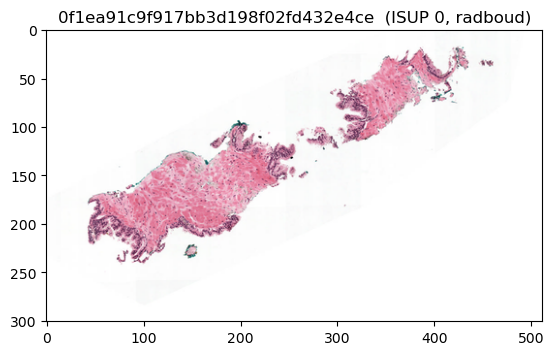

In [30]:
sample_image_id = train_df["image_id"].iloc[0]
slide = openslide.OpenSlide(train_images_dir + f"{sample_image_id}.tiff")

print("Level dimensions:", slide.level_dimensions)
print("Level downsamples:", slide.level_downsamples)

thumbnail = slide.get_thumbnail((512, 512))
plt.imshow(thumbnail)
plt.title(f"{sample_image_id}  (ISUP {train_df.iloc[0]['isup_grade']}, {train_df.iloc[0]['data_provider']})")

In [31]:
mask_ids = {Path(p).name.replace("_mask.tiff", "") for p in glob(train_masks_dir + "*.tiff")}

metadata_df = train_df.assign(
    has_mask=lambda df_: df_["image_id"].isin(mask_ids),
)
metadata_df

,image_id,data_provider,isup_grade,gleason_score,filepath,exists,has_mask
599,0f1ea91c9f917bb3d198f02fd432e4ce,radboud,0,negative,/home/shared/data/panda/train_images/0f1ea91c9...,True,False
695,117e082dcd41f3e3244100693ceef2b8,karolinska,0,0+0,/home/shared/data/panda/train_images/117e082dc...,True,False
880,164b35a1b6e77358640cd0d8554e396c,karolinska,0,0+0,/home/shared/data/panda/train_images/164b35a1b...,True,False
1196,1e642b4f5afa230c341c6622461dd48b,karolinska,0,0+0,/home/shared/data/panda/train_images/1e642b4f5...,True,False
1666,29d70921c5346342007bb79603c58303,radboud,0,negative,/home/shared/data/panda/train_images/29d70921c...,True,False
...,...,...,...,...,...,...,...
9477,e5a167f697628add6a45ea4e447465bd,karolinska,1,3+3,/home/shared/data/panda/train_images/e5a167f69...,True,False
9494,e62030f62fb52831cb29a000510c94a0,karolinska,0,0+0,/home/shared/data/panda/train_images/e62030f62...,True,False
9550,e76c7b4cbca487702e96526bf01bc165,karolinska,0,0+0,/home/shared/data/panda/train_images/e76c7b4cb...,True,False
10472,fce06ebb6c102f4f526a09e8273bded9,karolinska,0,0+0,/home/shared/data/panda/train_images/fce06ebb6...,True,False


### ISUP grade distribution

Are the 6 ISUP grades (0-5) roughly balanced, or is the dataset skewed toward benign/low-grade slides?

### Data provider comparison

Radboud and Karolinska use different scanners, staining, and (for Radboud) a finer-grained Gleason grading protocol. Compare grade distributions and a few thumbnails side by side to see how visually different the two sources are.

### Gleason score vs. ISUP grade

`isup_grade` is derived from `gleason_score`, but the mapping isn't 1:1 across providers — some `gleason_score` values are known to be mislabeled in the raw data (a well-documented PANDA quirk). Cross-tabulate the two columns, split by `data_provider`, to spot inconsistencies.

### Thumbnail grid across grades

Plot a grid with one row per ISUP grade and a few example slide thumbnails per row — a first visual sense of how tumor extent/morphology scales with grade.

### Label masks

For a slide that has a mask, load both the WSI thumbnail and the mask thumbnail side by side. Mask pixel values encode Gleason pattern / benign / background, but the encoding differs between Radboud and Karolinska — check the [data description](https://www.kaggle.com/c/prostate-cancer-grade-assessment/data) for the legend before interpreting colors.

### Mask coverage

Not every slide has a `train_label_masks` entry (`has_mask` above). Check what fraction of slides are missing a mask, and whether that's random or correlated with `data_provider` or `isup_grade`.

### WSI pyramid structure

Unlike the other two datasets, PANDA slides are full pyramidal TIFFs — each has multiple resolution levels (e.g. level 0 at native resolution, down to a small thumbnail-sized level). Inspect `level_dimensions`/`level_downsamples` across a few slides, and try reading a small region at full resolution with `read_region` to see actual cell-level detail (a thumbnail alone can't show this).

### Library to access PANDA data
There is no dataset-specific loader like `medmnist`/`wilds` here — OpenSlide is the library you'll use directly to read the raw WSIs. If you want you can explore it more:

In [32]:
slide = openslide.OpenSlide(train_images_dir + f"{sample_image_id}.tiff")

print("Dimensions (level 0):", slide.dimensions)
print("Num levels:", slide.level_count)
print("Properties (vendor, mpp, etc.):", dict(slide.properties))

slide.close()

Dimensions (level 0): (4352, 2560)
Num levels: 3
Properties (vendor, mpp, etc.): {'openslide.level-count': '3', 'openslide.level[0].downsample': '1', 'openslide.level[0].height': '2560', 'openslide.level[0].tile-height': '512', 'openslide.level[0].tile-width': '512', 'openslide.level[0].width': '4352', 'openslide.level[1].downsample': '4', 'openslide.level[1].height': '640', 'openslide.level[1].tile-height': '512', 'openslide.level[1].tile-width': '512', 'openslide.level[1].width': '1088', 'openslide.level[2].downsample': '16', 'openslide.level[2].height': '160', 'openslide.level[2].tile-height': '512', 'openslide.level[2].tile-width': '512', 'openslide.level[2].width': '272', 'openslide.mpp-x': '0.4861876369654638', 'openslide.mpp-y': '0.4861876369654638', 'openslide.quickhash-1': 'cdf6346a28a993d4e6a6f145567e67f2ae465732d53b0e022e0280627b6ea52e', 'openslide.vendor': 'generic-tiff', 'tiff.ResolutionUnit': 'centimeter', 'tiff.XResolution': '20568.190631943911', 'tiff.YResolution': '205

### Plotting a WSI and sampling patches from tissue

Two things worth showing explicitly with OpenSlide:

1. **Plotting the slide itself** — `get_thumbnail` decodes a low-resolution pyramid level directly, which is much faster than reading level 0 and downsampling manually.
2. **Finding a foreground (tissue) region** — most of a WSI's bounding box is blank slide background. A cheap way to find tissue is to threshold the thumbnail (Otsu on grayscale, tissue = darker than background), then sample patch coordinates from foreground pixels and read them at full resolution with `read_region`.


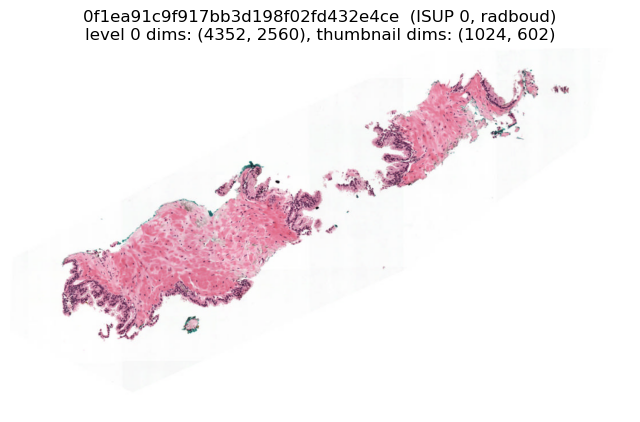

In [33]:
slide = openslide.OpenSlide(train_images_dir + f"{sample_image_id}.tiff")

thumbnail = slide.get_thumbnail((1024, 1024))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(thumbnail)
ax.set_title(
    f"{sample_image_id}  (ISUP {train_df.iloc[0]['isup_grade']}, {train_df.iloc[0]['data_provider']})\n"
    f"level 0 dims: {slide.dimensions}, thumbnail dims: {thumbnail.size}"
)
ax.axis("off")
plt.show()

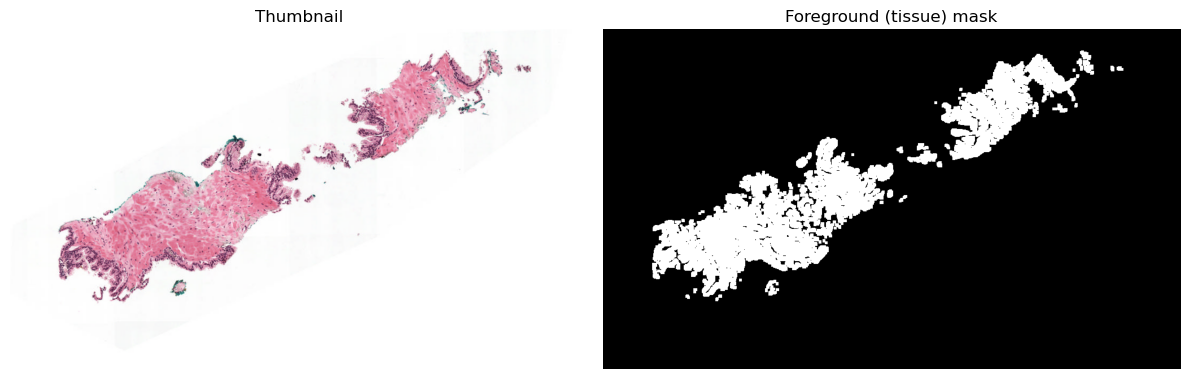

In [34]:
import cv2

# --- foreground (tissue) detection on the thumbnail ---
thumb_arr = np.array(thumbnail.convert("L"))
_, foreground_mask = cv2.threshold(
    thumb_arr, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
# drop small speckles so we don't sample isolated noise pixels
foreground_mask = cv2.morphologyEx(
    foreground_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8)
)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(thumbnail)
axs[0].set_title("Thumbnail")
axs[1].imshow(foreground_mask, cmap="gray")
axs[1].set_title("Foreground (tissue) mask")
for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()

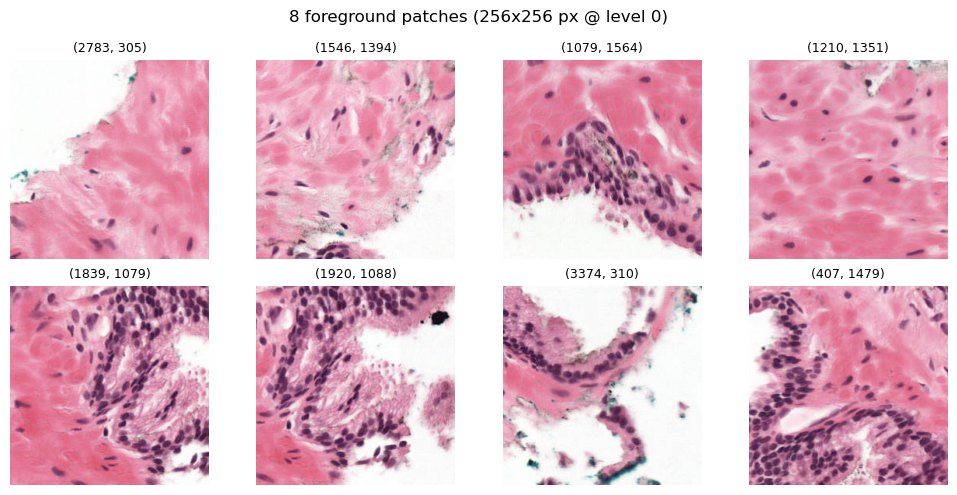

In [35]:
# --- sample patches from the foreground region at full (level 0) resolution ---
patch_size = 256
n_patches = 8
rng = np.random.default_rng(42)

# reopen the slide independently so this cell doesn't depend on execution order/state
# from the earlier thumbnail cell (which may have been closed by a previous run of this cell)
patch_slide = openslide.OpenSlide(train_images_dir + f"{sample_image_id}.tiff")

# map thumbnail pixel coords -> level-0 coords
scale_x = patch_slide.dimensions[0] / thumb_arr.shape[1]
scale_y = patch_slide.dimensions[1] / thumb_arr.shape[0]

fg_ys, fg_xs = np.nonzero(foreground_mask)
sample_idx = rng.choice(len(fg_xs), size=n_patches, replace=False)

fig, axs = plt.subplots(2, n_patches // 2, figsize=(2.5 * n_patches // 2, 5))
for ax, idx in zip(axs.flat, sample_idx):
    # center a level-0 patch on the sampled foreground pixel, clipped to stay on the slide
    cx = int(fg_xs[idx] * scale_x)
    cy = int(fg_ys[idx] * scale_y)
    x0 = int(np.clip(cx - patch_size // 2, 0, patch_slide.dimensions[0] - patch_size))
    y0 = int(np.clip(cy - patch_size // 2, 0, patch_slide.dimensions[1] - patch_size))

    patch = patch_slide.read_region((x0, y0), level=0, size=(patch_size, patch_size)).convert("RGB")
    ax.imshow(patch)
    ax.set_title(f"({x0}, {y0})", fontsize=9)
    ax.axis("off")

fig.suptitle(f"{n_patches} foreground patches ({patch_size}x{patch_size} px @ level 0)")
plt.tight_layout()
plt.show()

patch_slide.close()